In [2]:
import sys
import os

# Add src folder to Python path
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_ecg5000

plt.style.use("ggplot")

In [3]:
labels, signals = load_ecg5000()

print("Dataset Loaded Successfully\n")

print("Signals Shape :", signals.shape)
print("Labels Shape  :", labels.shape)

Dataset Loaded Successfully

Signals Shape : (5000, 140)
Labels Shape  : (5000,)


In [4]:
unique, counts = np.unique(labels, return_counts=True)

distribution = pd.DataFrame({
    "Class": unique,
    "Count": counts
})

distribution

,Class,Count
0,1,2919
1,2,1767
2,3,96
3,4,194
4,5,24


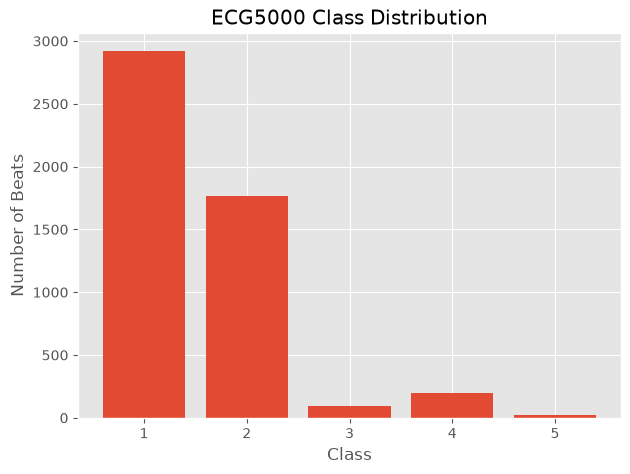

In [5]:
plt.figure(figsize=(7,5))

plt.bar(unique.astype(str), counts)

plt.title("ECG5000 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Beats")

plt.show()

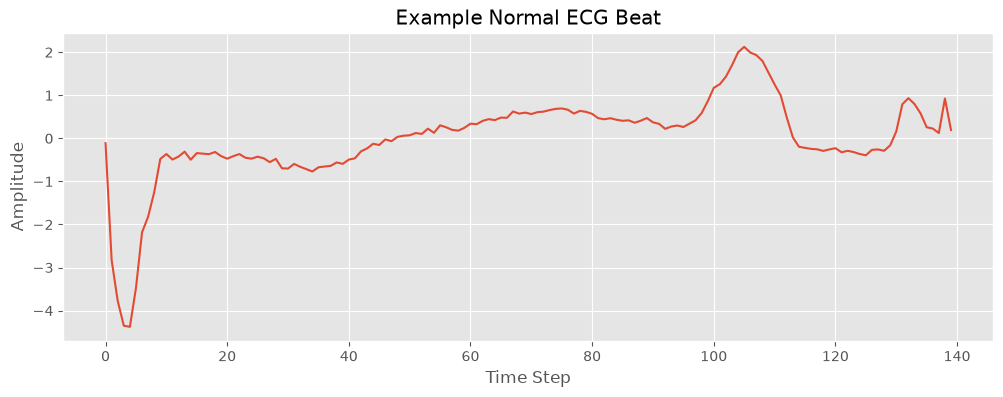

In [6]:
normal_index = np.where(labels == 1)[0][0]

plt.figure(figsize=(12,4))

plt.plot(signals[normal_index])

plt.title("Example Normal ECG Beat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

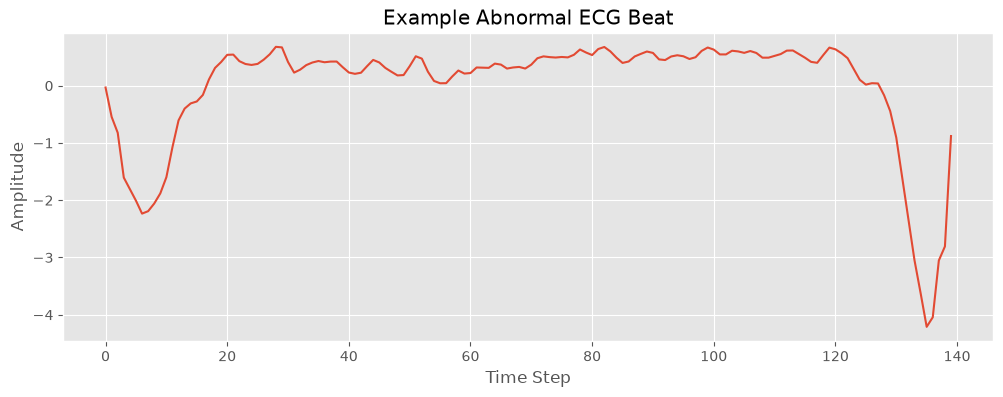

In [7]:
abnormal_index = np.where(labels != 1)[0][0]

plt.figure(figsize=(12,4))

plt.plot(signals[abnormal_index])

plt.title("Example Abnormal ECG Beat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

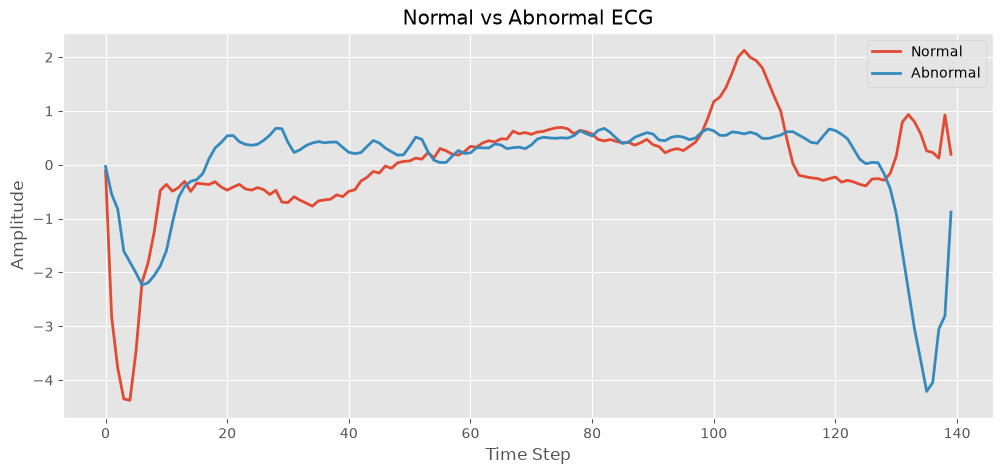

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    signals[normal_index],
    label="Normal",
    linewidth=2
)

plt.plot(
    signals[abnormal_index],
    label="Abnormal",
    linewidth=2
)

plt.legend()

plt.title("Normal vs Abnormal ECG")

plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

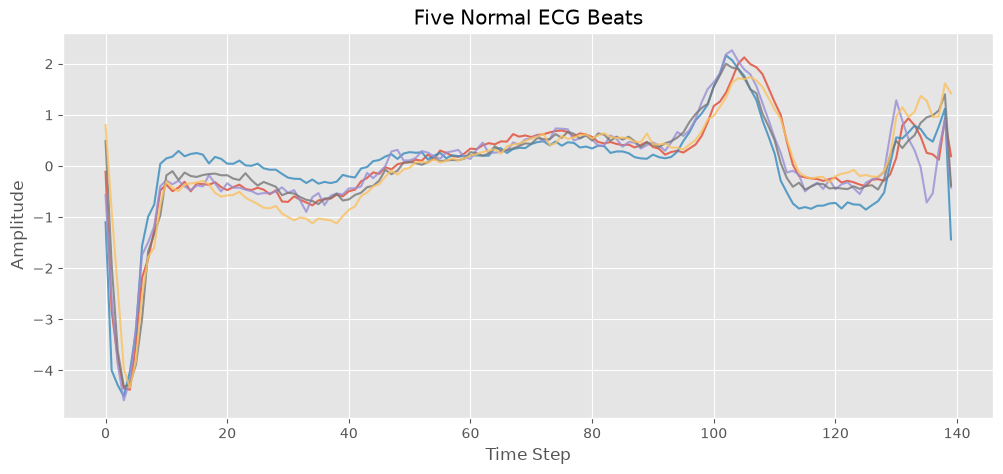

In [9]:
normal_indices = np.where(labels == 1)[0][:5]

plt.figure(figsize=(12,5))

for idx in normal_indices:
    plt.plot(signals[idx], alpha=0.8)

plt.title("Five Normal ECG Beats")

plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

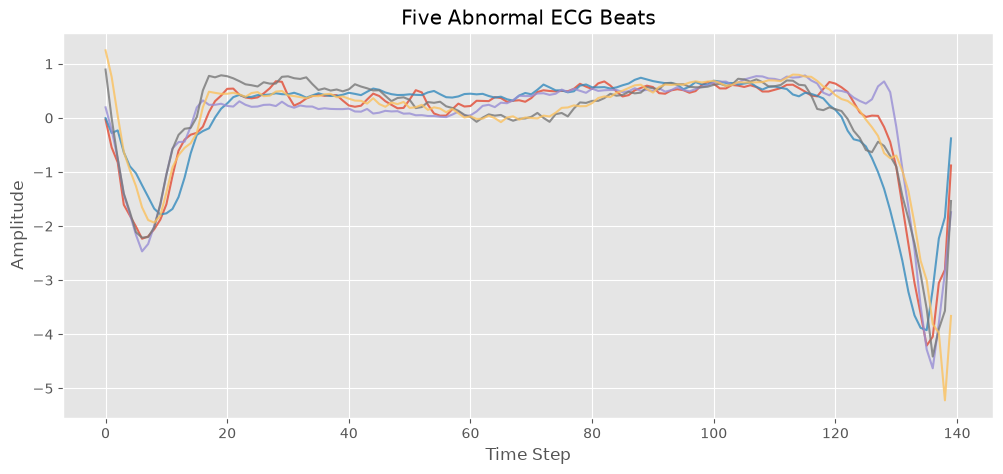

In [11]:
abnormal_indices = np.where(labels != 1)[0][:5]

plt.figure(figsize=(12,5))

for idx in abnormal_indices:
    plt.plot(signals[idx], alpha=0.8)

plt.title("Five Abnormal ECG Beats")

plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

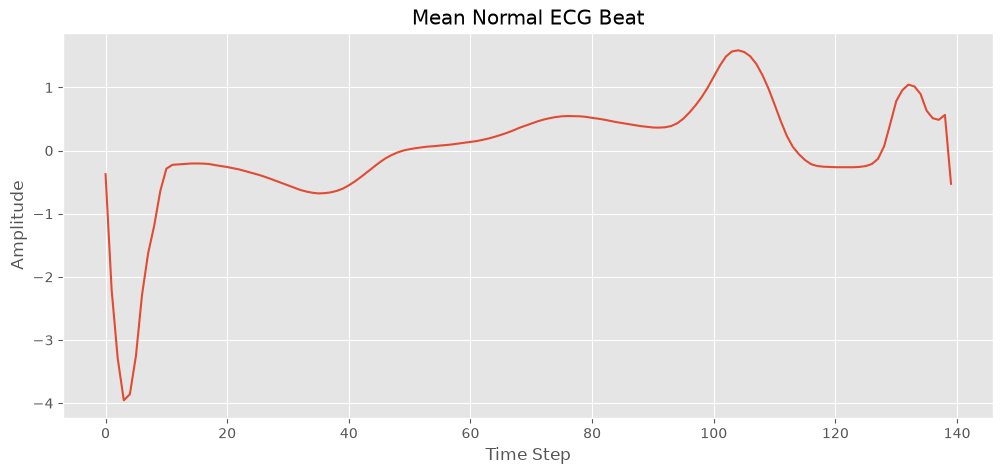

In [12]:
normal_signals = signals[labels == 1]

mean_normal = normal_signals.mean(axis=0)

plt.figure(figsize=(12,5))

plt.plot(mean_normal)

plt.title("Mean Normal ECG Beat")

plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

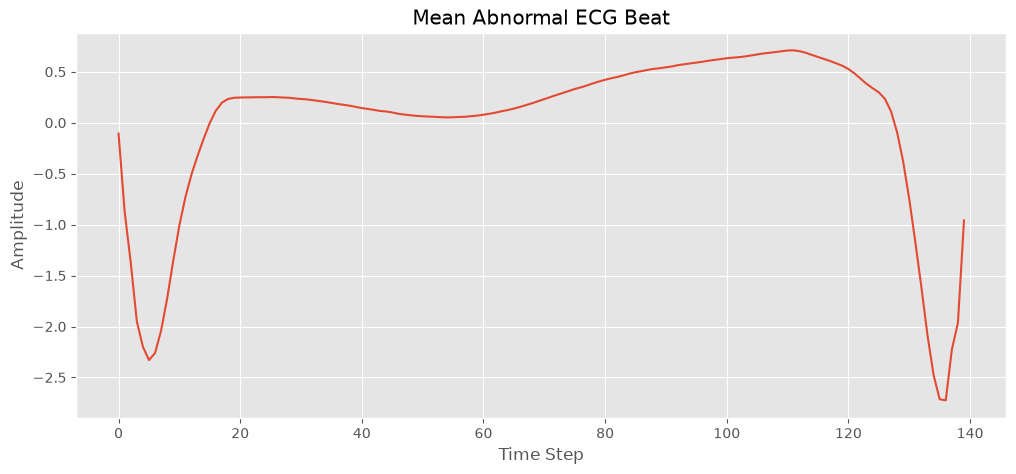

In [14]:
abnormal_signals = signals[labels != 1]

mean_abnormal = abnormal_signals.mean(axis=0)

plt.figure(figsize=(12,5))

plt.plot(mean_abnormal)

plt.title("Mean Abnormal ECG Beat")

plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.show()

In [15]:
print("Overall Statistics\n")

print("Minimum :", signals.min())
print("Maximum :", signals.max())
print("Mean    :", signals.mean())
print("Std     :", signals.std())

Overall Statistics

Minimum : -7.090374
Maximum : 7.402103
Mean    : 1.1160714e-08
Std     : 0.9964222


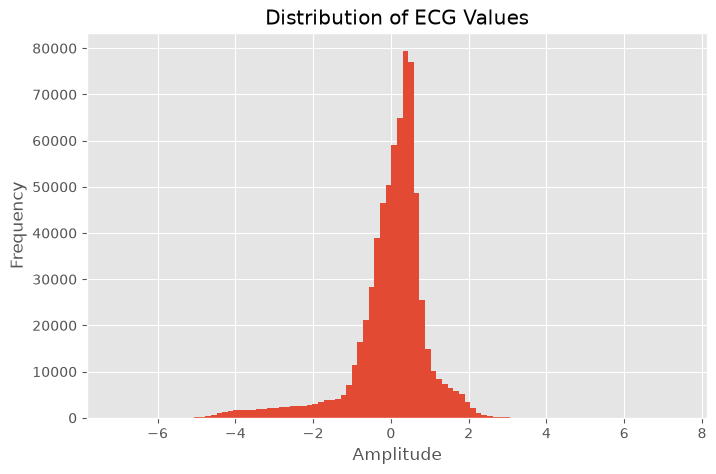

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    signals.flatten(),
    bins=100
)

plt.title("Distribution of ECG Values")

plt.xlabel("Amplitude")
plt.ylabel("Frequency")

plt.show()

In [17]:
print("Missing Values :", np.isnan(signals).sum())

Missing Values : 0


In [18]:
print("Number of ECG Beats :", len(labels))
print("Signal Length :", signals.shape[1])

print("\nClasses")

print(np.unique(labels))

Number of ECG Beats : 5000
Signal Length : 140

Classes
[1 2 3 4 5]
